Step 1: Dataset choice
Choose ONE classification dataset of your choice from any public repository -Kaggle or UCI.
It may be a binary classification problem or a multi-class
classification problem.

Minimum Feature Size: 12
Minimum Instance Size: 500

In [ ]:
import pandas as pd

# Load the 'heart.csv' file into a pandas DataFrame
df = pd.read_csv('./heart.csv')

# Display the first 5 rows of the DataFrame
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


Step 2: Machine Learning Classification models and Evaluation metrics
Implement the following classification models using the dataset chosen above. All
the 6 ML models have to be implemented on the same dataset.
1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbor Classifier
4. Naive Bayes Classifier - Gaussian or Multinomial
5. Ensemble Model - Random Forest

In [7]:
#Logistic Regression
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (820, 13)
X_test shape: (205, 13)
y_train shape: (820,)
y_test shape: (205,)


In [8]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled (first 5 rows):\n", X_train_scaled[:5])

X_train_scaled (first 5 rows):
 [[-5.85840222e-01  6.54653671e-01  1.00827500e+00 -7.79453566e-01
  -1.93503098e+00 -4.14039336e-01 -9.83741901e-01 -1.01909426e+00
  -7.25948939e-01 -2.10661213e-01  1.00526437e+00  2.17169136e+00
  -5.45193165e-01]
 [ 1.05147737e+00 -1.52752523e+00 -9.16720340e-01  2.74173173e+00
   1.61063407e+00 -4.14039336e-01  9.09845796e-01  2.02882145e-01
   1.37750735e+00 -9.12152360e-01  1.00526437e+00 -7.25467395e-01
  -5.45193165e-01]
 [-4.00676907e-02 -1.52752523e+00  1.00827500e+00 -1.34738668e+00
   4.42176271e-01 -4.14039336e-01 -9.83741901e-01  7.70228333e-01
  -7.25948939e-01 -9.12152360e-01  1.00526437e+00 -7.25467395e-01
  -5.45193165e-01]
 [ 5.05704840e-01  6.54653671e-01 -9.16720340e-01  1.86032724e-01
  -2.22635925e-01 -4.14039336e-01  9.09845796e-01  5.08376246e-01
  -7.25948939e-01 -4.73720393e-01 -6.40078509e-01 -7.25467395e-01
   1.11057867e+00]
 [-3.67531209e-01  6.54653671e-01  1.00827500e+00 -3.81900388e-01
  -1.03185928e-03  2.41522946e+00 

In [27]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model with Lasso (L1) regularization
# 'C' is the inverse of regularization strength; smaller values specify stronger regularization.
# 'liblinear' solver supports L1 penalty.
log_reg_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)

# Train the model
log_reg_model.fit(X_train_scaled, y_train)

print("Logistic Regression model with Lasso regularization trained successfully.")

Logistic Regression model with Lasso regularization trained successfully.


calculate the following evaluation metrics:
1. Accuracy
2. AUC Score
3. Precision
4. Recall
5. F1 Score
6. Matthews Correlation Coefficient (MCC Score)

In [26]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, matthews_corrcoef

# Make predictions on the scaled test set
y_pred_log_reg = log_reg_model.predict(X_test_scaled)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test_scaled)[:, 1] # Probability of the positive class

# Calculate evaluation metrics
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
auc_log_reg = roc_auc_score(y_test, y_pred_proba_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
mcc_log_reg = matthews_corrcoef(y_test, y_pred_log_reg)

print("--- Logistic Regression Metrics ---")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"AUC Score: {auc_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1 Score: {f1_log_reg:.4f}")
print(f"MCC Score: {mcc_log_reg:.4f}")

--- Logistic Regression Metrics ---
Accuracy: 0.7951
AUC Score: 0.8783
Precision: 0.7563
Recall: 0.8738
F1 Score: 0.8108
MCC Score: 0.5973


In [11]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree Classifier model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree Classifier model trained successfully.")


Decision Tree Classifier model trained successfully.


In [12]:
# Metrics calculation for Decision Tree Classifier
# Make predictions on the test set using the Decision Tree model
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for Decision Tree
accuracy_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
mcc_dt = matthews_corrcoef(y_test, y_pred_dt)

print("--- Decision Tree Classifier Metrics ---")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"AUC Score: {auc_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1 Score: {f1_dt:.4f}")
print(f"MCC Score: {mcc_dt:.4f}")

--- Decision Tree Classifier Metrics ---
Accuracy: 0.9854
AUC Score: 0.9854
Precision: 1.0000
Recall: 0.9709
F1 Score: 0.9852
MCC Score: 0.9712


In [13]:
#K-Nearest Neighbor Classifier
from sklearn.neighbors import KNeighborsClassifier

# Initialize K-Nearest Neighbor Classifier model
knn_model = KNeighborsClassifier()

# Train the model
knn_model.fit(X_train_scaled, y_train)

print("K-Nearest Neighbor Classifier model trained successfully.")

K-Nearest Neighbor Classifier model trained successfully.


In [14]:
# Metrics calculation for K-Nearest Neighbor Classifier
# Make predictions on the scaled test set using the KNN model
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_pred_proba_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
mcc_knn = matthews_corrcoef(y_test, y_pred_knn)

print("--- K-Nearest Neighbor Classifier Metrics ---")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"AUC Score: {auc_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1 Score: {f1_knn:.4f}")
print(f"MCC Score: {mcc_knn:.4f}")

--- K-Nearest Neighbor Classifier Metrics ---
Accuracy: 0.8341
AUC Score: 0.9486
Precision: 0.8000
Recall: 0.8932
F1 Score: 0.8440
MCC Score: 0.6727


In [17]:
#Naive Bayes Classifier - Gaussian or Multinomial
from sklearn.naive_bayes import GaussianNB

# Initialize Gaussian Naive Bayes model
gnb_model = GaussianNB()

# Train the model
gnb_model.fit(X_train_scaled, y_train)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


In [18]:
# Metrics calculation for Gaussian Naive Bayes Classifier
# Make predictions on the scaled test set using the GNB model
y_pred_gnb = gnb_model.predict(X_test_scaled)
y_pred_proba_gnb = gnb_model.predict_proba(X_test_scaled)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for GNB
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
auc_gnb = roc_auc_score(y_test, y_pred_proba_gnb)
precision_gnb = precision_score(y_test, y_pred_gnb)
recall_gnb = recall_score(y_test, y_pred_gnb)
f1_gnb = f1_score(y_test, y_pred_gnb)
mcc_gnb = matthews_corrcoef(y_test, y_pred_gnb)

print("--- Gaussian Naive Bayes Classifier Metrics ---")
print(f"Accuracy: {accuracy_gnb:.4f}")
print(f"AUC Score: {auc_gnb:.4f}")
print(f"Precision: {precision_gnb:.4f}")
print(f"Recall: {recall_gnb:.4f}")
print(f"F1 Score: {f1_gnb:.4f}")
print(f"MCC Score: {mcc_gnb:.4f}")

--- Gaussian Naive Bayes Classifier Metrics ---
Accuracy: 0.8000
AUC Score: 0.8706
Precision: 0.7541
Recall: 0.8932
F1 Score: 0.8178
MCC Score: 0.6102


In [19]:
#Ensemble Model - Random Forest
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

print("Random Forest Classifier model trained successfully.")

Random Forest Classifier model trained successfully.


In [20]:
# Metrics calculation for Random Forest Classifier
# Make predictions on the scaled test set using the RF model
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1] # Probability of the positive class

# Calculate evaluation metrics for RF
accuracy_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)

print("--- Random Forest Classifier Metrics ---")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"AUC Score: {auc_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print(f"MCC Score: {mcc_rf:.4f}")

--- Random Forest Classifier Metrics ---
Accuracy: 0.9854
AUC Score: 1.0000
Precision: 1.0000
Recall: 0.9709
F1 Score: 0.9852
MCC Score: 0.9712


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dictionary to store all metrics
metrics_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'K-Nearest Neighbor', 'Gaussian Naive Bayes', 'Random Forest'],
    'Accuracy': [accuracy_log_reg, accuracy_dt, accuracy_knn, accuracy_gnb, accuracy_rf],
    'AUC Score': [auc_log_reg, auc_dt, auc_knn, auc_gnb, auc_rf],
    'Precision': [precision_log_reg, precision_dt, precision_knn, precision_gnb, precision_rf],
    'Recall': [recall_log_reg, recall_dt, recall_knn, recall_gnb, recall_rf],
    'F1 Score': [f1_log_reg, f1_dt, f1_knn, f1_gnb, f1_rf],
    'MCC Score': [mcc_log_reg, mcc_dt, mcc_knn, mcc_gnb, mcc_rf]
}

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

,Model,Accuracy,AUC Score,Precision,Recall,F1 Score,MCC Score
0,Logistic Regression,0.795122,0.878736,0.756303,0.873786,0.810811,0.597255
1,Decision Tree,0.985366,0.985437,1.000000,0.970874,0.985222,0.971151
2,K-Nearest Neighbor,0.834146,0.948553,0.800000,0.893204,0.844037,0.672727
3,Gaussian Naive Bayes,0.800000,0.870550,0.754098,0.893204,0.817778,0.610224
4,Random Forest,0.985366,1.000000,1.000000,0.970874,0.985222,0.971151


/tmp/ipykernel_4549/278725892.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_4549/278725892.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_4549/278725892.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_4549/278725892.py:9: FutureWarning: 

Passing `palette` without assigning `hue`

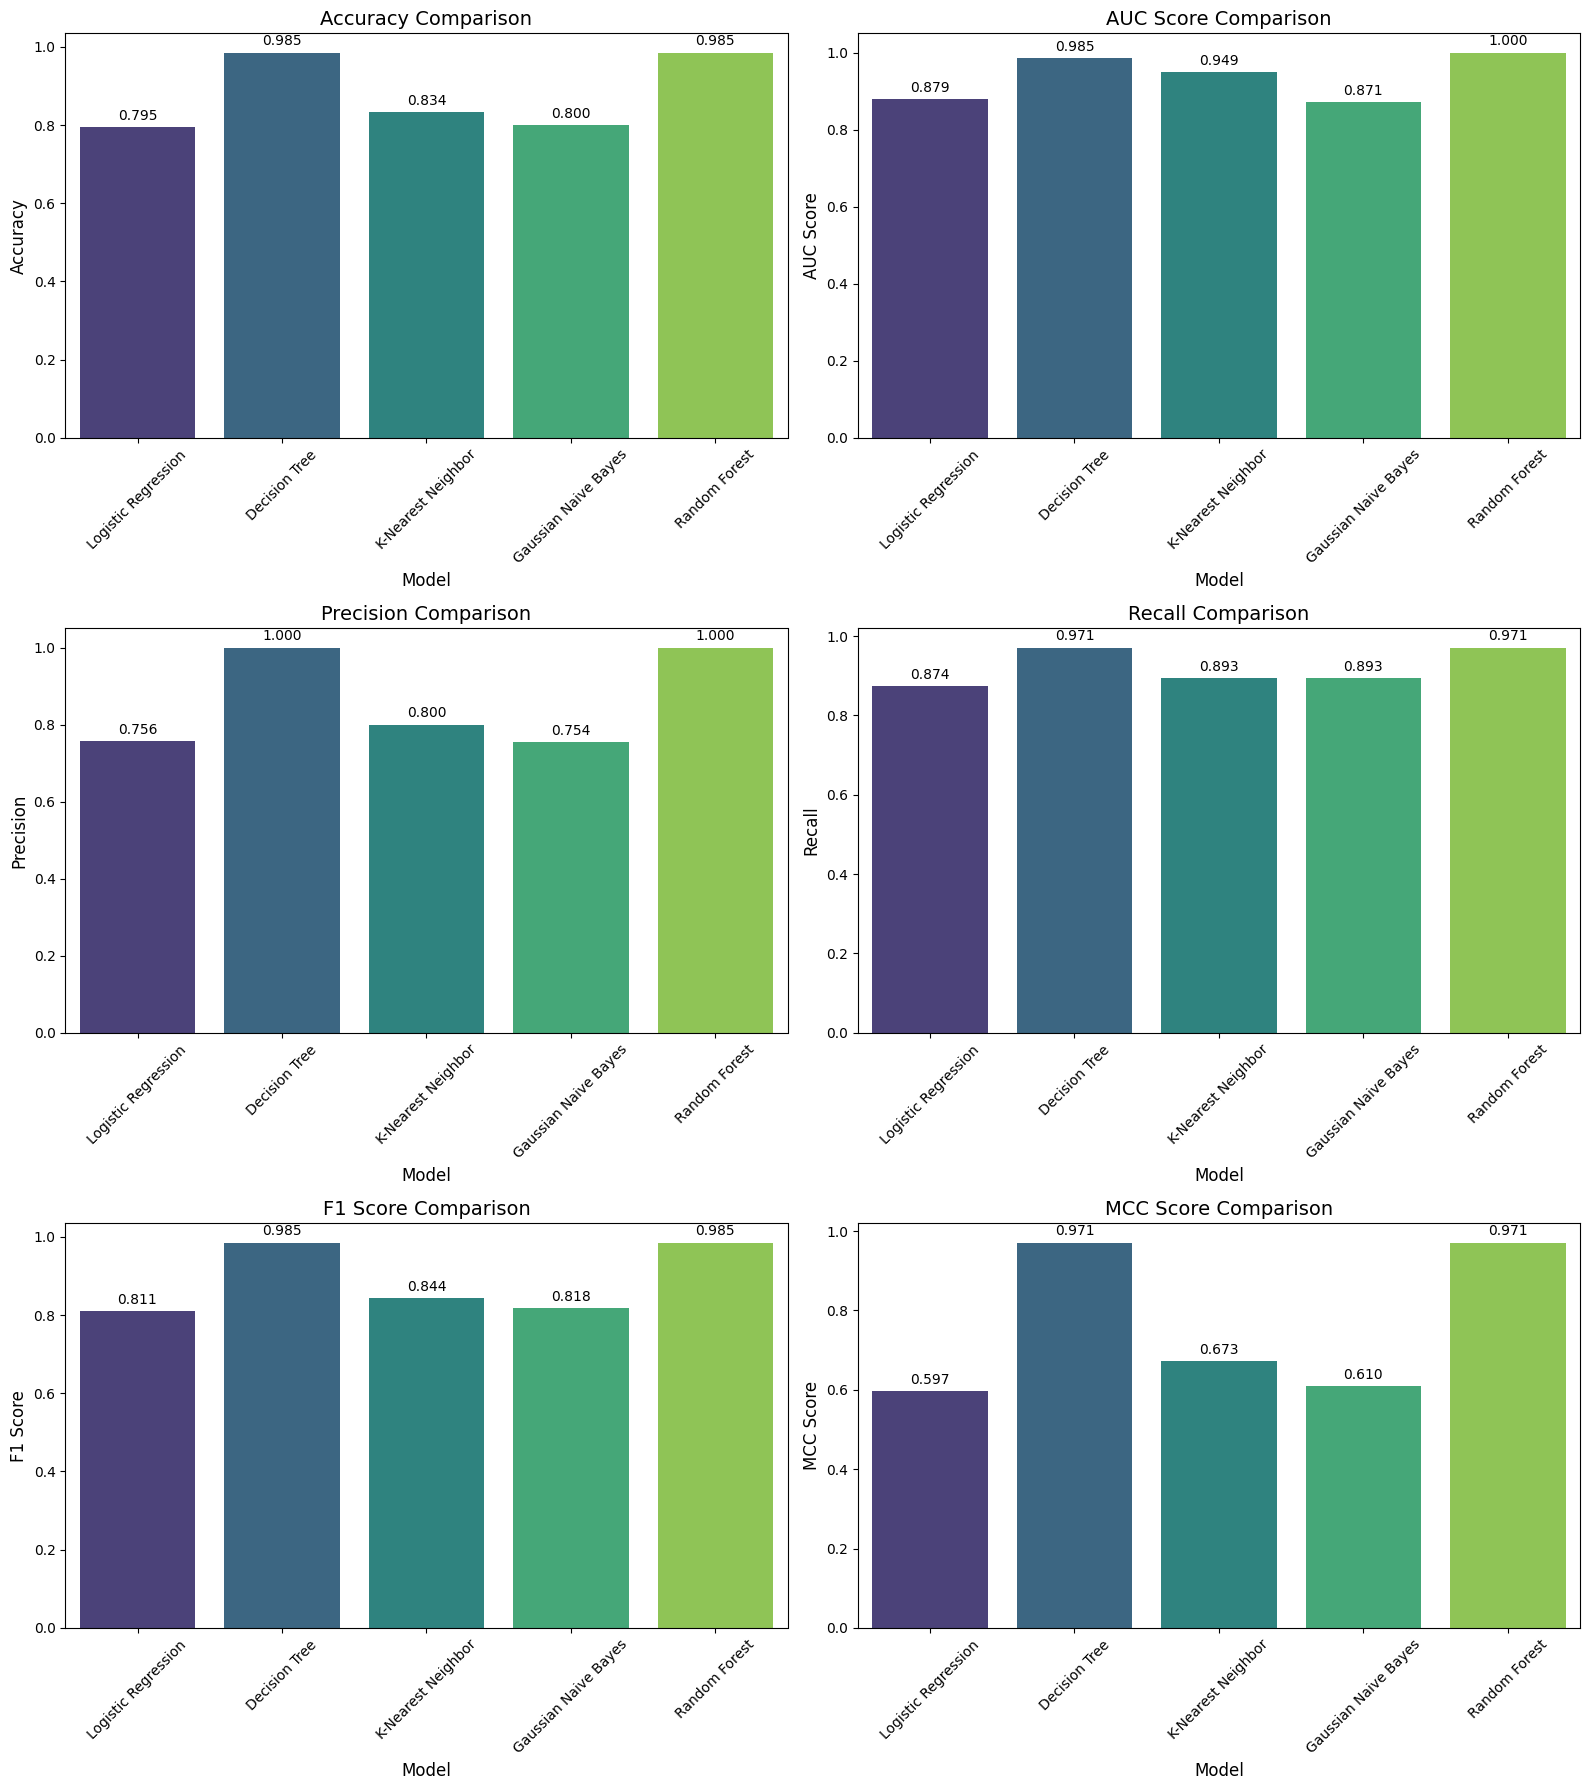

In [28]:
# Plotting the comparison

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

metrics = ['Accuracy', 'AUC Score', 'Precision', 'Recall', 'F1 Score', 'MCC Score']

for i, metric in enumerate(metrics):
    sns.barplot(x='Model', y=metric, data=metrics_df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{metric} Comparison', fontsize=14)
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].set_xlabel('Model', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    # Add value labels on top of the bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()